# Rain Classification — Visualise, Split, Train & Save
Daily classes: <1 No/Minimal, 1–<10 Low, 10–<100 Moderate, ≥100 High.


In [20]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, joblib
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,ConfusionMatrixDisplay
R=Path.cwd(); R=R if R.name.lower()=="rain" else (R/"Rain" if (R/"Rain").exists() else R.parent/"Rain")
D=R/"dataset"/"rain_preprocessed.csv"; M=R/"trained_models"; M.mkdir(exist_ok=True)
F=["temperature_2m_max","temperature_2m_min","relative_humidity_2m_mean","dew_point_2m_mean","cloud_cover_mean","pressure_msl_mean","wind_speed_10m_max","shortwave_radiation_sum","month"]
T="rain_class"; C=["No/Minimal Rain","Low","Moderate","High"]
df=pd.read_csv(D); df["date"]=pd.to_datetime(df.date)
print(df.shape,df.date.min(),df.date.max()); display(df.head()); display(df[F+["rain_sum",T]].isna().sum().to_frame("missing"))


(458679, 15) 2021-01-01 00:00:00 2026-01-31 00:00:00


,date,prefecture,town,location_id,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,dew_point_2m_mean,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_max,shortwave_radiation_sum,month,rain_sum,rain_class
0,2021-01-01,Aichi,Nagoya,0,5.2,-3.2,76.0,-2.1,49.0,1019.3,25.1,8.04,1,0.1,No/Minimal Rain
1,2021-01-01,Akita,Oga,3,-2.6,-4.8,66.0,-8.8,71.0,1013.7,41.9,7.33,1,0.0,No/Minimal Rain
2,2021-01-01,Kyoto,Fukuchiyama,2,3.8,-4.8,74.0,-2.8,67.0,1020.9,14.9,6.65,1,0.0,No/Minimal Rain
3,2021-01-01,Ibaraki,Hitachi,1,5.1,-2.1,52.0,-6.8,25.0,1013.5,15.4,8.28,1,0.0,No/Minimal Rain
4,2021-01-01,Okinawa,Miyakoshima,2,17.2,14.4,65.0,9.9,54.0,1023.5,26.9,11.84,1,0.0,No/Minimal Rain


,missing
temperature_2m_max,0
temperature_2m_min,0
relative_humidity_2m_mean,29712
dew_point_2m_mean,0
cloud_cover_mean,29712
pressure_msl_mean,29712
wind_speed_10m_max,0
shortwave_radiation_sum,0
month,0
rain_sum,0


In [21]:
missing_by_prefecture = (
    df.groupby("prefecture")[F]
      .apply(lambda x: x.isna().sum())
)

display(
    missing_by_prefecture[
        (missing_by_prefecture > 0).any(axis=1)
    ]
)

,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,dew_point_2m_mean,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_max,shortwave_radiation_sum,month
prefecture,,,,,,,,,
mie,0,0,7428,0,7428,7428,0,0,0
nara,0,0,7428,0,7428,7428,0,0,0
shiga,0,0,7428,0,7428,7428,0,0,0
shizuoka,0,0,7428,0,7428,7428,0,0,0


## Plot 1 — Class distribution
Check class imbalance before training.


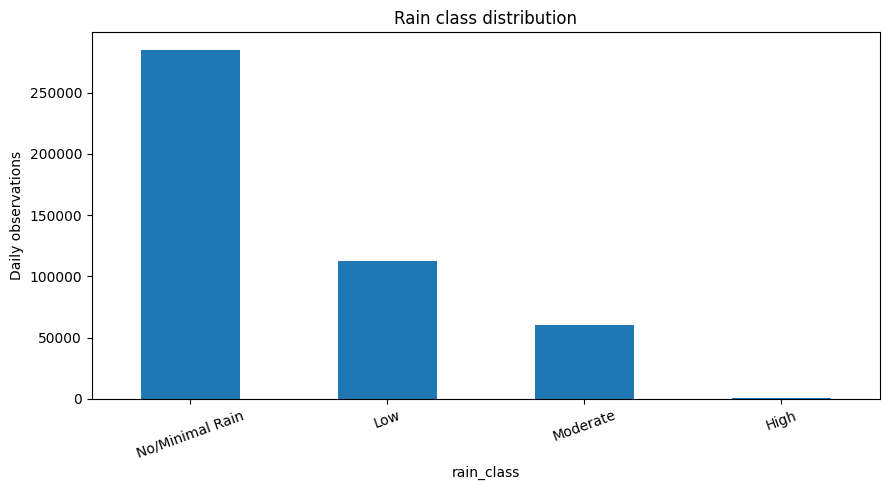

,count,percent
rain_class,,
No/Minimal Rain,285021,62.14
Low,112813,24.60
Moderate,60185,13.12
High,660,0.14


In [22]:
counts=df[T].value_counts().reindex(C,fill_value=0); counts.plot(kind="bar",figsize=(9,5)); plt.title("Rain class distribution"); plt.ylabel("Daily observations"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
display(pd.DataFrame({"count":counts,"percent":(100*counts/counts.sum()).round(2)}))


## Plot 2 — Daily rainfall distribution


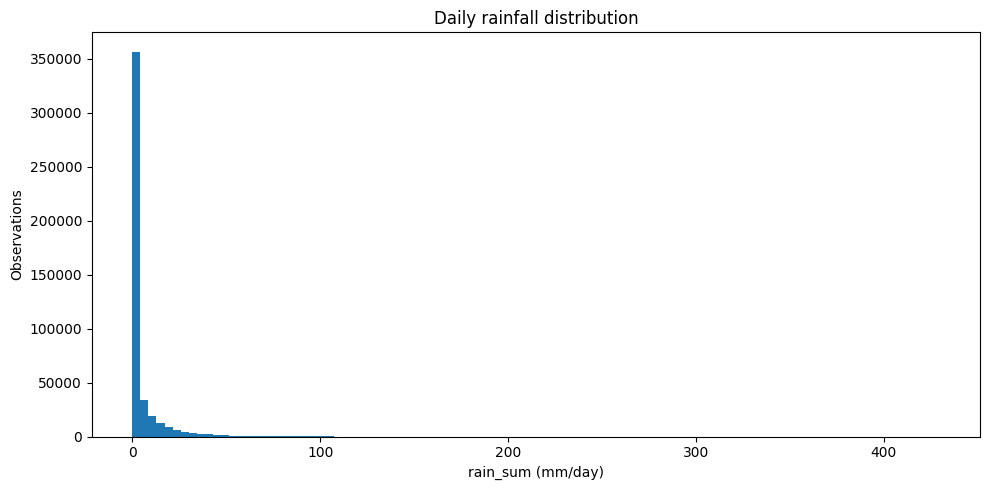

count    458679.000000
mean          4.502095
std          11.327081
min           0.000000
50%           0.200000
75%           3.300000
90%          13.800000
95%          24.400000
99%          54.000000
99.5%        68.500000
99.9%       111.200000
max         429.700000
Name: rain_sum, dtype: float64

In [23]:
plt.figure(figsize=(10,5)); plt.hist(df.rain_sum.dropna(),bins=100); plt.title("Daily rainfall distribution"); plt.xlabel("rain_sum (mm/day)"); plt.ylabel("Observations"); plt.tight_layout(); plt.show()
display(df.rain_sum.describe(percentiles=[.5,.75,.9,.95,.99,.995,.999]))


## Plot 3 — Monthly class distribution


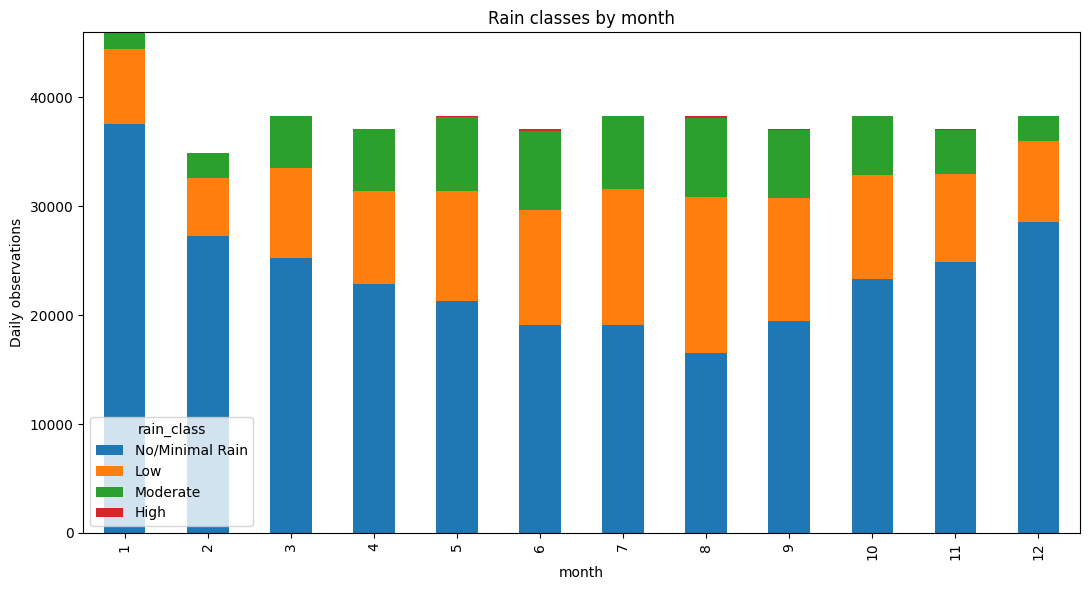

In [24]:
pd.crosstab(df.month,df[T]).reindex(columns=C,fill_value=0).plot(kind="bar",stacked=True,figsize=(11,6)); plt.title("Rain classes by month"); plt.ylabel("Daily observations"); plt.tight_layout(); plt.show()


## Plot 4 — Correlation heatmap


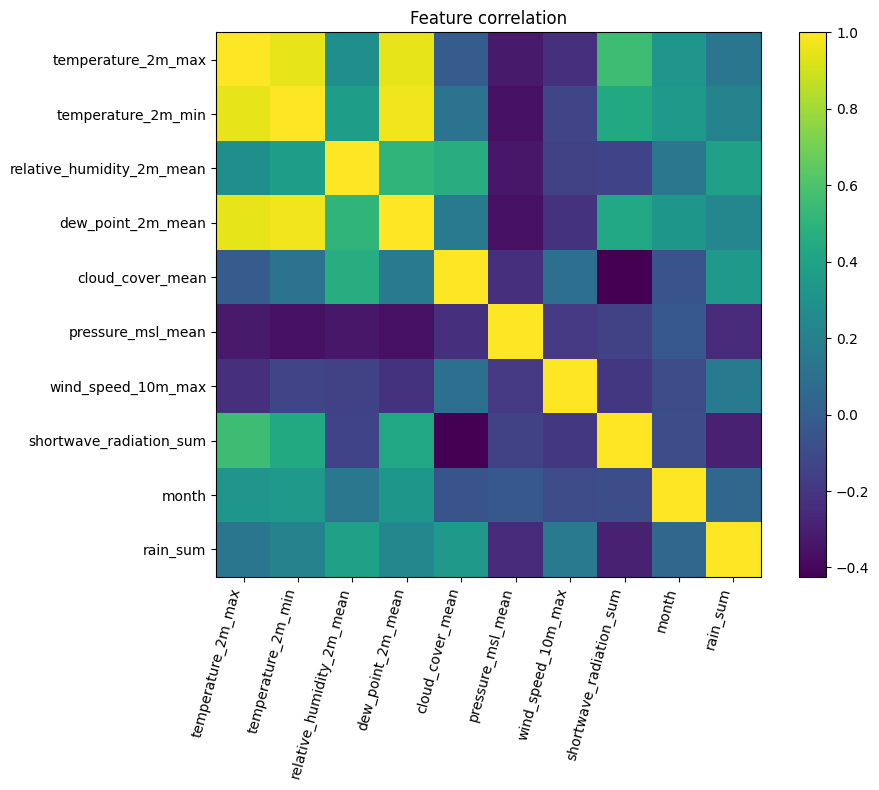

In [25]:
corr=df[F+["rain_sum"]].corr(); fig,ax=plt.subplots(figsize=(10,8)); im=ax.imshow(corr); ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr))); ax.set_xticklabels(corr.columns,rotation=75,ha="right"); ax.set_yticklabels(corr.columns); fig.colorbar(im,ax=ax); plt.title("Feature correlation"); plt.tight_layout(); plt.show()


## Chronological split
2023–2025 = training; 2026 = testing. `rain_sum` is not an X feature because it creates the target.


In [26]:
req=F+[T,"date"]; missing=[c for c in req if c not in df]; assert not missing,f"Missing: {missing}"
d=df.dropna(subset=req).copy(); train=d[d.date.dt.year.between(2023, 2025)].copy(); test=d[d.date.dt.year==2026].copy()
assert len(train) and len(test),"Need 2023-2025 training data and 2026 testing data"
Xtr,ytr=train[F],train[T]; Xte,yte=test[F],test[T]
train.to_csv(M/"training.csv",index=False); test.to_csv(M/"testing.csv",index=False)
print("Train",len(train),train.date.min(),train.date.max()); print("Test",len(test),test.date.min(),test.date.max())
display(pd.DataFrame({"train":ytr.value_counts().reindex(C,fill_value=0),"test":yte.value_counts().reindex(C,fill_value=0)}))


Train 253176 2023-01-01 00:00:00 2025-12-31 00:00:00
Test 7161 2026-01-01 00:00:00 2026-01-31 00:00:00


,train,test
rain_class,,
No/Minimal Rain,155368,6260
Low,64720,809
Moderate,32759,92
High,329,0


## Train four classifiers


In [27]:
models={"Gradient Boosting":GradientBoostingClassifier(random_state=42),"Random Forest":RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1,class_weight="balanced"),"CART":DecisionTreeClassifier(random_state=42,class_weight="balanced")}
rows=[]; preds={}
for name,m in models.items():
 print("Training",name); m.fit(Xtr,ytr); p=m.predict(Xte); preds[name]=p
 rows.append({"Model":name,"Accuracy":accuracy_score(yte,p),"Macro Precision":precision_score(yte,p,average="macro",zero_division=0),"Macro Recall":recall_score(yte,p,average="macro",zero_division=0),"Macro F1":f1_score(yte,p,average="macro",zero_division=0)})
results=pd.DataFrame(rows).sort_values("Macro F1",ascending=False); display(results)


Training Gradient Boosting
Training Random Forest
Training CART


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Random Forest,0.900433,0.744604,0.523526,0.575982
0,Gradient Boosting,0.897919,0.683340,0.491837,0.531708
2,CART,0.845413,0.495819,0.517167,0.505504


## Detailed reports and confusion matrices



 Gradient Boosting
                 precision    recall  f1-score   support

No/Minimal Rain       0.92      0.97      0.95      6260
            Low       0.60      0.40      0.48       809
       Moderate       0.53      0.10      0.17        92
           High       0.00      0.00      0.00         0

       accuracy                           0.90      7161
      macro avg       0.51      0.37      0.40      7161
   weighted avg       0.88      0.90      0.89      7161



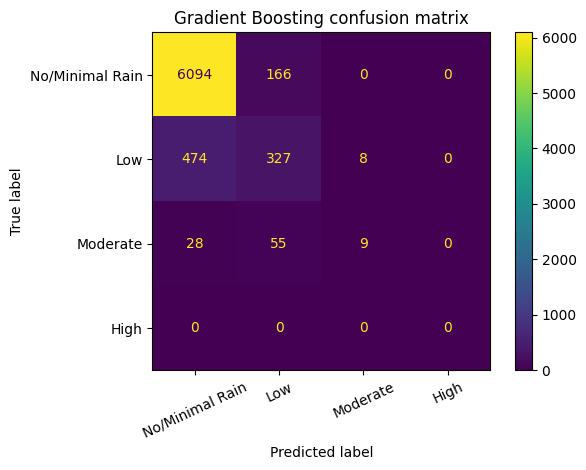


 Random Forest
                 precision    recall  f1-score   support

No/Minimal Rain       0.93      0.97      0.95      6260
            Low       0.61      0.42      0.50       809
       Moderate       0.70      0.17      0.28        92
           High       0.00      0.00      0.00         0

       accuracy                           0.90      7161
      macro avg       0.56      0.39      0.43      7161
   weighted avg       0.89      0.90      0.89      7161



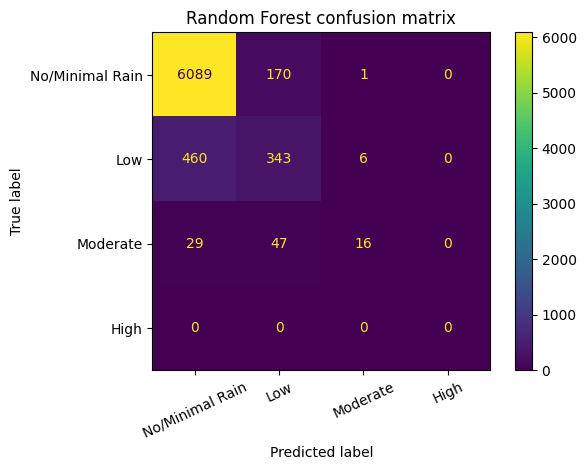


 CART
                 precision    recall  f1-score   support

No/Minimal Rain       0.93      0.91      0.92      6260
            Low       0.36      0.41      0.39       809
       Moderate       0.19      0.23      0.21        92
           High       0.00      0.00      0.00         0

       accuracy                           0.85      7161
      macro avg       0.37      0.39      0.38      7161
   weighted avg       0.86      0.85      0.85      7161



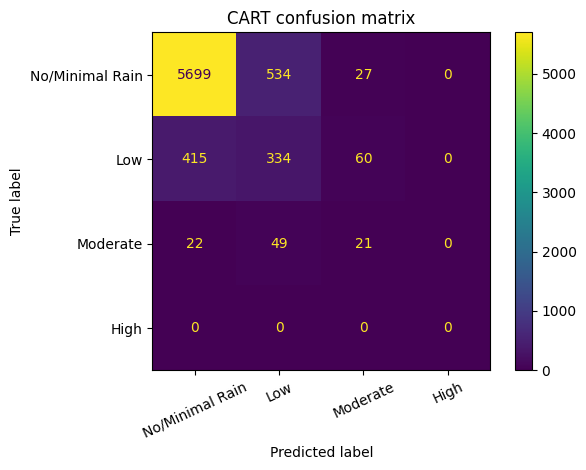

In [28]:
for name,p in preds.items():
 print("\n",name); print(classification_report(yte,p,labels=C,zero_division=0))
 ConfusionMatrixDisplay.from_predictions(yte,p,labels=C,xticks_rotation=25); plt.title(name+" confusion matrix"); plt.tight_layout(); plt.show()


## Feature importance


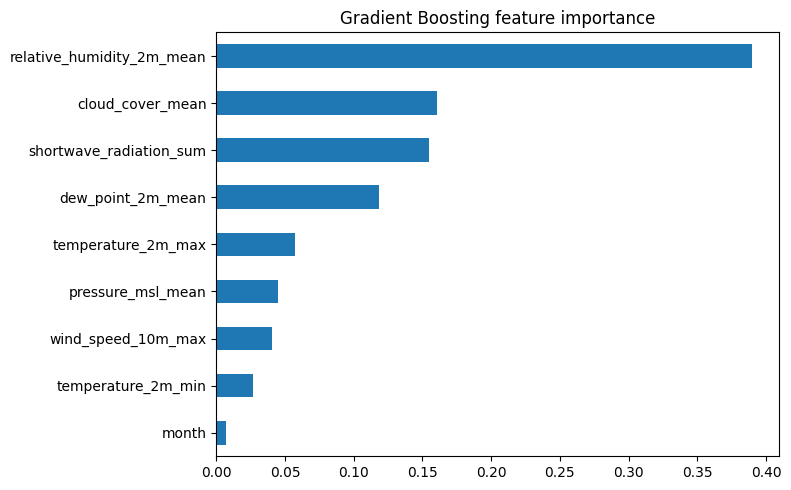

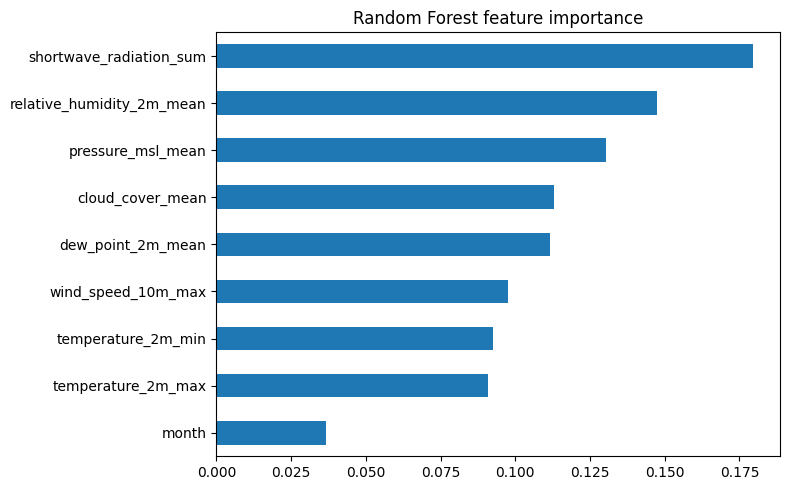

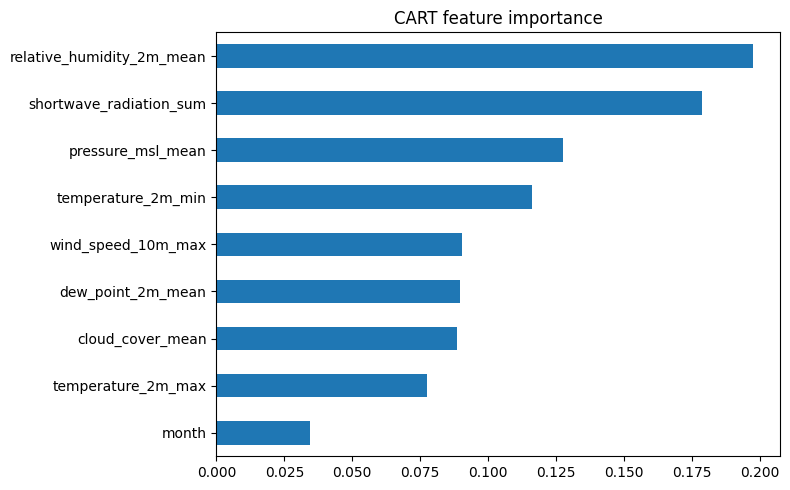

In [29]:
for name in ["Gradient Boosting","Random Forest","CART"]:
 pd.Series(models[name].feature_importances_,index=F).sort_values().plot(kind="barh",figsize=(8,5)); plt.title(name+" feature importance"); plt.tight_layout(); plt.show()


## Save models and results


In [30]:
names={"Gradient Boosting":"gradient_boosting.joblib","Random Forest":"random_forest.joblib","CART":"cart.joblib"}
for n,m in models.items(): joblib.dump(m,M/names[n]); print("Saved",M/names[n])
results.to_csv(M/"model_results.csv",index=False); print("Done:",M)


Saved c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Rain\trained_models\gradient_boosting.joblib
Saved c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Rain\trained_models\random_forest.joblib
Saved c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Rain\trained_models\cart.joblib
Done: c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Rain\trained_models
